# L1 · 등가직사각형 응력블록 — 근사를 어디까지 믿을 것인가

## 이 시간에 답할 질문

1. 콘크리트 압축응력은 실제로 곡선인데, 왜 직사각형으로 바꿔 놓고 푸는가?
2. $\eta$ 와 $\beta_1$ 은 어디서 나온 숫자인가?
3. 그 근사는 얼마나 정확한가. 그리고 **어디서 깨지는가**?
4. 근사가 위험한 쪽으로 틀리는 경우가 있는가?

## 기준이 허용하는 것

KDS 14 20 20 4.1.1(6)은 압축응력 분포를 **직사각형·사다리꼴·포물선 등
실험과 일치하는 어떤 형상으로도 가정할 수 있다**고 규정한다. 그리고
구체적으로 두 가지를 제시한다.

| 조문 | 관계 | 성격 |
|---|---|---|
| 4.1.1(7), 표 4.1-1 | **포물선-직선** — 식 (4.1-1), (4.1-2) | 실제 거동에 가까운 쪽 |
| 4.1.1(8), 표 4.1-2 | **등가직사각형 응력블록** — $\eta(0.85f_{ck})$, $a=\beta_1 c$ | 손으로 풀기 위한 근사 |

둘 중 어느 쪽을 써도 좋다. 이 시간에는 두 관계를 직접 그려 비교하고,
차이가 어디서 커지는지 확인한다.

:::{tip}
같은 내용을 슬라이더로 움직여 보려면
[대화형 탐색기](../_static/explorer.html)를 연다. 값을 바꾸면 그래프가 바로
따라 바뀐다.
:::

## 0. 준비

**아래 코드가 하는 일** — 그림에 쓸 한글 글꼴을 찾아 등록하고, 단면
분류에 쓸 색을 정한다. 글꼴을 못 찾으면 경고만 내고 넘어가므로 셀이
실패하지는 않는다.

In [1]:
%matplotlib inline

import glob
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager


def use_korean_font():
    """설치된 한글 글꼴을 찾아 matplotlib 에 등록한다."""
    site = Path(sys.prefix, "lib", f"python{sys.version_info.major}.{sys.version_info.minor}", "site-packages")
    for pattern in (
        str(site / "koreanize_matplotlib/fonts/*.ttf"),
        "/usr/share/fonts/**/*Nanum*.ttf",
        "/usr/share/fonts/**/*NotoSansCJK*.ot[fc]",
        "/usr/share/fonts/**/*NotoSansKR*.otf",
    ):
        for path in glob.glob(pattern, recursive=True):
            font_manager.fontManager.addfont(path)

    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in ("NanumGothic", "Malgun Gothic", "AppleGothic",
                 "Noto Sans CJK KR", "Noto Sans KR", "WenQuanYi Zen Hei"):
        if name in installed:
            plt.rcParams["font.family"] = name
            return name

    warnings.warn(
        "한글 글꼴을 찾지 못했다. 그림의 한글이 깨진다면 "
        "`pip install koreanize-matplotlib` 로 글꼴만 내려받거나, "
        "나눔고딕·Noto Sans KR 을 시스템에 설치한다.",
        stacklevel=2,
    )
    return None


print("사용 글꼴:", use_korean_font())

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# 단면 분류에 쓰는 색 (압축지배 · 변화구간 · 인장지배)
C_COMP, C_TRAN, C_TENS = "#ad3327", "#b5811f", "#2a7355"
BAND = {"압축지배단면": C_COMP, "변화구간단면": C_TRAN, "인장지배단면": C_TENS}

사용 글꼴: NanumGothic


**아래 코드가 하는 일** — 이 노트북 전체에서 쓸 보·기둥 단면을 만드는
함수를 정의한다. `profile` 인자로 극한 응력-변형률 관계를 고를 수 있게
해 두었다. `"block"` 은 등가직사각형 응력블록, `"parabolic"` 은
포물선-직선 관계다.

보는 **압축철근을 두지 않았다**(`n_top=0`). 손계산 공식과 조건을 정확히
맞추기 위해서다. 압축철근이 있으면 차이가 근사 때문인지 압축철근 때문인지
구분할 수 없다.

In [2]:
from concreteproperties import ConcreteSection
from sectionproperties.pre.library import concrete_rectangular_section

from concreteproperties_kds import KDS


def beam(fck=27, fy=400, n_bar=4, d=600, b=400, cover=50, profile="block"):
    """단철근 직사각형 보. 압축철근이 없어 손계산과 조건이 정확히 같다."""
    kds = KDS()
    conc = kds.create_concrete_material(
        compressive_strength=fck, ultimate_profile=profile
    )
    steel = kds.create_steel_material(yield_strength=fy)

    geom = concrete_rectangular_section(
        d=d, b=b,
        dia_top=22, area_top=387.1, n_top=0, c_top=cover,
        dia_bot=22, area_bot=387.1, n_bot=n_bar, c_bot=cover,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    kds.assign_concrete_section(ConcreteSection(geom))
    return kds


def column(fck=27, fy=400, column_type="tie", profile="block"):
    """500 x 500 기둥 (8-D22, 피복 50 mm)."""
    kds = KDS(column_type=column_type)
    conc = kds.create_concrete_material(
        compressive_strength=fck, ultimate_profile=profile
    )
    steel = kds.create_steel_material(yield_strength=fy)

    geom = concrete_rectangular_section(
        d=500, b=500,
        dia_top=22, area_top=387.1, n_top=3, c_top=50,
        dia_bot=22, area_bot=387.1, n_bot=3, c_bot=50,
        dia_side=22, area_side=387.1, n_side=1, c_side=50,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    kds.assign_concrete_section(ConcreteSection(geom))
    return kds


def depth(kds):
    """단면 상단에서 최하단 철근 도심까지의 유효깊이 d."""
    sec = kds.concrete_section
    top = sec.compound_geometry.geom.bounds[3]
    return top - min(g.calculate_centroid()[1] for g in sec.reinf_geometries_lumped)


print("보와 기둥을 만드는 함수를 정의했다.")

보와 기둥을 만드는 함수를 정의했다.


## 1. 실제 응력분포 — 포물선-직선 관계

KDS 14 20 20 식 (4.1-1), (4.1-2)는 압축응력을 이렇게 정의한다.

$$
f_c = 0.85 f_{ck}\left[1 - \left(1 - \frac{\varepsilon_c}
{\varepsilon_{co}}\right)^{n}\right]
\qquad (\varepsilon_c \leq \varepsilon_{co})
$$

$$
f_c = 0.85 f_{ck}
\qquad (\varepsilon_{co} < \varepsilon_c \leq \varepsilon_{cu})
$$

변형률 $\varepsilon_{co}$ 까지는 포물선으로 올라가고, 그 뒤 극한변형률
$\varepsilon_{cu}$ 까지는 최대값을 유지한다. 지수 $n$, $\varepsilon_{co}$,
$\varepsilon_{cu}$ 는 강도에 따라 달라진다 — 식 (4.1-3)~(4.1-5).

**왜 강도가 높을수록 $n$ 이 작아지는가.** 고강도 콘크리트는 파괴가
취성적이라 응력-변형률 곡선이 더 뾰족해지고 하강이 급하다. $n$ 이 작아지면
곡선이 더 빨리 최대값에 도달하는 모양이 되어 그 거동을 반영한다. 동시에
$\varepsilon_{cu}$ 는 줄어든다 — 덜 늘어나고 깨진다는 뜻이다.

**아래 코드가 하는 일** — 강도별로 $n$, $\varepsilon_{co}$,
$\varepsilon_{cu}$, $\alpha$, $\beta$ 를 뽑아 KDS 표 4.1-1 과 대조한다.

In [3]:
from concreteproperties_kds import parabolic_parameters, parabolic_stress
from concreteproperties_kds import stress_block_parameters

print("KDS 14 20 20 표 4.1-1 — 포물선-직선 관계")
print(f"{'fck':>5} {'n':>7} {'εco':>9} {'εcu':>9} {'α':>7} {'β':>7}")
print("-" * 48)
for fck in (40, 50, 60, 70, 80, 90):
    n, eps_co, eps_cu, alpha, beta = parabolic_parameters(fck)
    print(f"{fck:5.0f} {n:7.2f} {eps_co:9.4f} {eps_cu:9.4f} {alpha:7.2f} {beta:7.2f}")

print()
print("KDS 14 20 20 표 4.1-2 — 등가직사각형 응력블록")
print(f"{'fck':>5} {'εcu':>9} {'η':>7} {'β1':>7}")
print("-" * 32)
for fck in (40, 50, 60, 70, 80, 90):
    eps_cu, eta, beta_1 = stress_block_parameters(fck)
    print(f"{fck:5.0f} {eps_cu:9.4f} {eta:7.2f} {beta_1:7.2f}")

KDS 14 20 20 표 4.1-1 — 포물선-직선 관계
  fck       n       εco       εcu       α       β
------------------------------------------------
   40    2.00    0.0020    0.0033    0.80    0.40
   50    1.92    0.0021    0.0032    0.78    0.40
   60    1.50    0.0022    0.0031    0.72    0.38
   70    1.29    0.0023    0.0030    0.67    0.37
   80    1.22    0.0024    0.0029    0.63    0.36
   90    1.20    0.0025    0.0028    0.59    0.35

KDS 14 20 20 표 4.1-2 — 등가직사각형 응력블록
  fck       εcu       η      β1
--------------------------------
   40    0.0033    1.00    0.80
   50    0.0032    0.97    0.80
   60    0.0031    0.95    0.76
   70    0.0030    0.91    0.74
   80    0.0029    0.87    0.72
   90    0.0028    0.84    0.70


**아래 코드가 하는 일** — 포물선-직선 곡선을 강도별로 그린다. 최대값을
$0.85f_{ck}$ 로 나눠 정규화했으므로, 곡선의 **모양**만 비교된다.

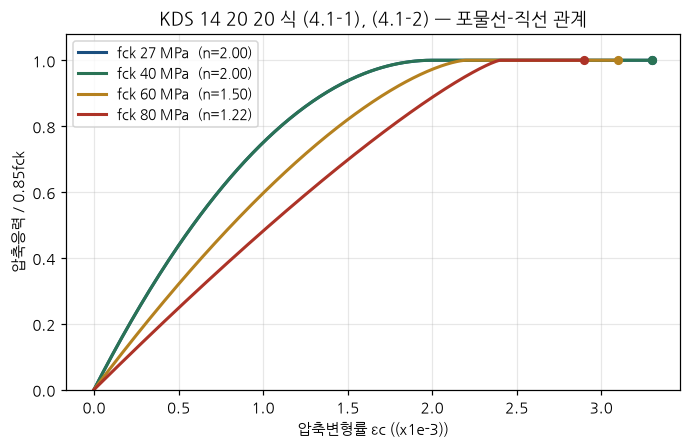

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))

for fck, colour in zip([27, 40, 60, 80], ["#1b4f7f", "#2a7355", "#b5811f", "#ad3327"]):
    n, eps_co, eps_cu, _, _ = parabolic_parameters(fck)
    eps = np.linspace(0, eps_cu, 300)
    f_c = np.array([parabolic_stress(fck, e) for e in eps])
    ax.plot(eps * 1000, f_c / (0.85 * fck), color=colour, lw=2,
            label=f"fck {fck} MPa  (n={n:.2f})")
    ax.plot([eps_cu * 1000], [1.0], "o", color=colour, ms=5)

ax.set_xlabel("압축변형률 εc ((x1e-3))")
ax.set_ylabel("압축응력 / 0.85fck")
ax.set_title("KDS 14 20 20 식 (4.1-1), (4.1-2) — 포물선-직선 관계")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.08)
plt.show()

점으로 찍은 것이 각 곡선의 끝, 즉 극한변형률 $\varepsilon_{cu}$ 다.
강도가 높을수록 **왼쪽에서 끝난다** — 덜 변형하고 깨진다.

## 2. 등가블록은 무엇을 같게 맞춘 것인가

직사각형으로 바꿔치기해도 되려면 두 가지가 같아야 한다.

1. **합력의 크기** — 응력분포의 면적
2. **합력의 작용 위치** — 응력분포의 도심

이 둘만 같으면 단면의 힘 평형과 모멘트 평형이 그대로 성립한다. 분포의
모양이 다른 것은 상관없다. 바로 이것이 등가블록의 전부다.

KDS 는 포물선-직선 분포에 대해 평균 압축응력 계수 $\alpha$ 와 합력
위치 계수 $\beta$ 를 표 4.1-1 에 주고 있으므로, 직접 확인할 수 있다.

$$
\text{합력} = \alpha (0.85 f_{ck})\, b\, c
\qquad
\text{작용 위치} = \beta c \ \text{(압축연단에서)}
$$

등가블록은 같은 것을 이렇게 쓴다.

$$
\text{합력} = \eta (0.85 f_{ck})\, b\, (\beta_1 c)
\qquad
\text{작용 위치} = \frac{\beta_1 c}{2}
$$

**아래 코드가 하는 일** — 두 표현이 정말 같은 값을 주는지 확인한다.
합력 비 $\eta\beta_1 / \alpha$ 와 위치 비 $(\beta_1/2)/\beta$ 가 1 에
가까우면 등가가 성립한다.

In [5]:
print(f"{'fck':>5} {'α':>7} {'ηβ1':>7} {'합력비':>8}   {'β':>7} {'β1/2':>7} {'위치비':>8}")
print("-" * 60)
for fck in (40, 50, 60, 70, 80, 90):
    _, _, _, alpha, beta = parabolic_parameters(fck)
    _, eta, beta_1 = stress_block_parameters(fck)
    print(f"{fck:5.0f} {alpha:7.2f} {eta * beta_1:7.3f} {eta * beta_1 / alpha:8.3f}   "
          f"{beta:7.2f} {beta_1 / 2:7.3f} {(beta_1 / 2) / beta:8.3f}")

  fck       α     ηβ1      합력비         β    β1/2      위치비
------------------------------------------------------------
   40    0.80   0.800    1.000      0.40   0.400    1.000
   50    0.78   0.776    0.995      0.40   0.400    1.000
   60    0.72   0.722    1.003      0.38   0.380    1.000
   70    0.67   0.673    1.005      0.37   0.370    1.000
   80    0.63   0.626    0.994      0.36   0.360    1.000
   90    0.59   0.588    0.997      0.35   0.350    1.000


두 도심선이 거의 겹쳐 보인다면 제대로 본 것이다. $\beta c$ 와 $a/2$ 가
같아지도록 $\beta_1$ 을 정했으니 당연한 결과이고, 이것이 등가블록이
성립하는 이유 그 자체다.

**여기서 알 것.** 합력비와 위치비가 모두 1 근처다. 즉 $\eta$, $\beta_1$
은 임의로 정한 숫자가 아니라 **포물선-직선 분포의 면적과 도심을 맞춘
결과**다. 완전히 1 이 아닌 것은 표 값을 실용적인 자리수로 반올림했기
때문이다.

**아래 코드가 하는 일** — 400 × 600 단철근 보의 극한상태를 실제로 풀어
중립축 깊이 $c$ 를 구한 뒤, 세 장면을 같은 높이 축에 나란히 그린다.

1. **단면** — 압축연단이 위, 인장철근이 아래. 중립축 위쪽 빗금이 압축부다.
2. **변형률** — 평면유지 가정이므로 직선이다. 압축연단에서
   $\varepsilon_{cu}$, 철근 위치에서 $\varepsilon_t$.
3. **압축응력** — 그 변형률에 대응하는 응력. 포물선-직선과 등가블록을
   겹쳐 놓았다.

세 그림의 세로 위치가 서로 맞으므로, 어느 높이의 변형률이 어떤 응력을
만드는지 눈으로 따라갈 수 있다.

/tmp/ipykernel_2937/453613771.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


중립축 c = 84.3 mm,  압축블록 a = 67.5 mm,  유효깊이 d = 539 mm
포물선 합력 = 619 kN   (작용 위치 βc = 33.7 mm)
블록  합력 = 619 kN   (작용 위치 a/2 = 33.7 mm)


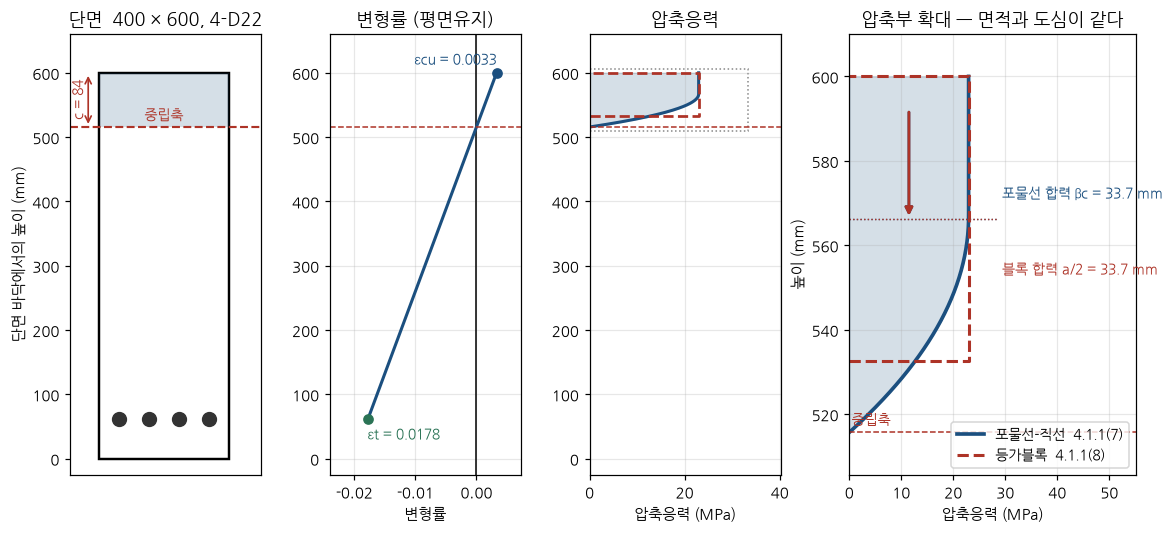

In [6]:
fck, fy, n_bar = 27, 400, 4     # ← 값을 바꿔 보라
H, B, COVER = 600.0, 400.0, 50.0

# 실제 극한상태를 풀어 중립축 깊이를 얻는다
kds_b = beam(fck=fck, fy=fy, n_bar=n_bar, d=H, b=B, cover=COVER)
_, u_res, _ = kds_b.ultimate_bending_capacity()
c = u_res.d_n
d_eff = depth(kds_b)

n, eps_co, eps_cu, alpha, beta = parabolic_parameters(fck)
_, eta, beta_1 = stress_block_parameters(fck)
a = beta_1 * c
f_blk = eta * 0.85 * fck

y_na = H - c            # 중립축의 높이 (바닥 기준)
y_bar = H - d_eff       # 인장철근의 높이
eps_t = eps_cu * (d_eff - c) / c

fig = plt.figure(figsize=(12.5, 5.2))
gs = fig.add_gridspec(1, 4, width_ratios=[1.0, 1.0, 1.0, 1.5], wspace=0.32)
axes = [fig.add_subplot(gs[0])]
axes += [fig.add_subplot(gs[k], sharey=axes[0]) for k in (1, 2)]
zoom = fig.add_subplot(gs[3])

# ── (1) 단면 ──────────────────────────────────────────────────
ax = axes[0]
ax.add_patch(plt.Rectangle((0, 0), B, H, fill=False, ec="k", lw=1.6))
ax.add_patch(plt.Rectangle((0, y_na), B, c, facecolor="#1b4f7f",
                           alpha=0.18, ec="none"))
for i_bar in range(n_bar):
    x = COVER + 11 + i_bar * (B - 2 * (COVER + 11)) / max(n_bar - 1, 1)
    ax.plot([x], [y_bar], "o", color="#333", ms=9)
ax.axhline(y_na, color=C_COMP, lw=1.4, ls="--")
ax.text(B / 2, y_na + 12, "중립축", color=C_COMP, ha="center", fontsize=9)
ax.annotate("", xy=(-34, H), xytext=(-34, y_na),
            arrowprops=dict(arrowstyle="<->", color=C_COMP, lw=1.1))
ax.text(-44, (H + y_na) / 2, f"c = {c:.0f}", rotation=90, ha="right",
        va="center", color=C_COMP, fontsize=9)
ax.set_xlim(-90, B + 100)
ax.set_title(f"단면  {B:.0f} × {H:.0f}, {n_bar}-D22")
ax.set_ylabel("단면 바닥에서의 높이 (mm)")
ax.set_xticks([])
ax.grid(False)

# ── (2) 변형률 ────────────────────────────────────────────────
ax = axes[1]
ax.axvline(0, color="k", lw=1.0)
ax.plot([eps_cu, -eps_t], [H, y_bar], color="#1b4f7f", lw=2)
ax.axhline(y_na, color=C_COMP, lw=1.0, ls="--")
ax.plot([eps_cu], [H], "o", color="#1b4f7f", ms=6)
ax.plot([-eps_t], [y_bar], "o", color=C_TENS, ms=6)
ax.text(eps_cu, H + 14, f"εcu = {eps_cu:.4f}", ha="right",
        color="#1b4f7f", fontsize=9)
ax.text(-eps_t, y_bar - 30, f"εt = {eps_t:.4f}", ha="left",
        color=C_TENS, fontsize=9)
ax.set_title("변형률 (평면유지)")
ax.set_xlabel("변형률")
ax.set_xlim(-eps_t * 1.35, eps_cu * 2.2)

# ── (3) 압축응력 (단면 전체 높이) ─────────────────────────────
yy = np.linspace(y_na, H, 300)
f_para = np.array([parabolic_stress(fck, eps_cu * (h - y_na) / c) for h in yy])

ax = axes[2]
ax.fill_betweenx(yy, 0, f_para, color="#1b4f7f", alpha=0.18)
ax.plot(f_para, yy, color="#1b4f7f", lw=2)
ax.plot([0, f_blk, f_blk, 0], [H - a, H - a, H, H],
        color=C_COMP, lw=1.8, ls="--")
ax.axhline(y_na, color=C_COMP, lw=1.0, ls="--")
ax.add_patch(plt.Rectangle((0, y_na - 6), f_blk * 1.45, c + 12,
                           fill=False, ec="#888", lw=1.0, ls=":"))
ax.set_title("압축응력")
ax.set_xlabel("압축응력 (MPa)")
ax.set_xlim(0, f_blk * 1.75)

# ── (4) 압축부 확대 ───────────────────────────────────────────
zoom.fill_betweenx(yy, 0, f_para, color="#1b4f7f", alpha=0.18)
zoom.plot(f_para, yy, color="#1b4f7f", lw=2.4, label="포물선-직선  4.1.1(7)")
zoom.plot([0, f_blk, f_blk, 0], [H - a, H - a, H, H],
          color=C_COMP, lw=2, ls="--", label="등가블록  4.1.1(8)")
zoom.axhline(y_na, color=C_COMP, lw=1.0, ls="--")
zoom.text(f_blk * 0.02, y_na + 2, "중립축", color=C_COMP, fontsize=9)

for y_res, colour, lab, dy in [
    (H - beta * c, "#1b4f7f", f"포물선 합력 βc = {beta * c:.1f} mm", 6),
    (H - a / 2, C_COMP, f"블록 합력 a/2 = {a / 2:.1f} mm", -12),
]:
    zoom.annotate("", xy=(f_blk * 0.5, y_res), xytext=(f_blk * 0.5, y_res + 26),
                  arrowprops=dict(arrowstyle="-|>", color=colour, lw=1.8))
    zoom.plot([0, f_blk * 1.25], [y_res, y_res], color=colour, lw=0.9, ls=":")
    zoom.text(f_blk * 1.28, y_res + dy, lab, color=colour, fontsize=9, va="center")

zoom.set_title("압축부 확대 — 면적과 도심이 같다")
zoom.set_xlabel("압축응력 (MPa)")
zoom.set_ylabel("높이 (mm)")
zoom.set_xlim(0, f_blk * 2.4)
zoom.set_ylim(y_na - 10, H + 10)
zoom.legend(loc="lower right", fontsize=9)

axes[0].set_ylim(-25, H + 60)
fig.tight_layout()

print(f"중립축 c = {c:.1f} mm,  압축블록 a = {a:.1f} mm,  유효깊이 d = {d_eff:.0f} mm")
print(f"포물선 합력 = {alpha * 0.85 * fck * B * c / 1e3:,.0f} kN"
      f"   (작용 위치 βc = {beta * c:.1f} mm)")
print(f"블록  합력 = {f_blk * B * a / 1e3:,.0f} kN"
      f"   (작용 위치 a/2 = {a / 2:.1f} mm)")

## 3. 설계의 의도 — 왜 굳이 근사를 두는가

포물선-직선 관계로도 풀 수 있는데 왜 블록을 따로 규정할까.

**손으로 풀 수 있게 하려는 것이다.** 포물선 분포의 합력을 구하려면 중립축
깊이를 모르는 상태에서 적분을 해야 하고, 그 적분은 강도마다 다르다.
직사각형이면 합력이 곧 $\eta(0.85f_{ck}) \cdot b \cdot \beta_1 c$ 이고,
힘 평형 $C = T$ 에서 $a$ 가 **한 줄로** 나온다.

$$
a = \frac{A_s f_y}{\eta (0.85 f_{ck})\, b}
$$

설계기준은 계산기가 없던 시절부터 실무자가 종이 위에서 안전한 답을 얻도록
만들어져 왔다. 등가블록은 그 산물이다. 컴퓨터로 단면을 잘라 적분할 수 있는
지금도 블록이 남아 있는 이유는, **검산이 가능해야 하기 때문**이다. 남의
해석 결과를 받아 들었을 때 손으로 짚어 볼 수단이 없으면 검증이 성립하지
않는다.

## 4. 그래서 얼마나 정확한가 — 휨부재

**아래 코드가 하는 일** — 같은 보를 두 관계로 각각 풀어 설계휨강도를
비교한다. 철근 개수를 늘려 가며 차이가 어떻게 변하는지 본다.

In [7]:
rows = []
for n_bar in range(2, 11):
    m_block = beam(n_bar=n_bar, profile="block").ultimate_bending_capacity()[1].m_x
    m_para = beam(n_bar=n_bar, profile="parabolic").ultimate_bending_capacity()[1].m_x
    rows.append((n_bar, m_block / 1e6, m_para / 1e6))

print(f"{'철근':>6} {'블록 Mn':>10} {'포물선 Mn':>11} {'차이':>8}")
print("-" * 38)
for n_bar, mb, mp in rows:
    print(f"{n_bar:4d}-D22 {mb:10.1f} {mp:11.1f} {(mp / mb - 1) * 100:7.2f} %")

    철근      블록 Mn      포물선 Mn       차이
--------------------------------------
   2-D22      161.7       161.5   -0.10 %
   3-D22      238.6       238.2   -0.16 %
   4-D22      312.9       312.3   -0.21 %
   5-D22      384.6       383.6   -0.27 %
   6-D22      453.7       452.2   -0.33 %
   7-D22      520.2       518.2   -0.40 %
   8-D22      584.1       581.4   -0.46 %
   9-D22      645.4       642.0   -0.53 %
  10-D22      704.0       699.8   -0.60 %


**차이가 0.3 % 를 넘지 않는다.** 근사치고는 놀라울 만큼 잘 맞는다.

**왜 이렇게 잘 맞는가.** 휨강도는 $M_n = T \cdot z$ 인데, $T = A_s f_y$
는 응력분포와 **무관하고**, 지렛대 팔 $z = d - (\text{합력 위치})$ 에서
합력 위치는 두 분포가 같도록 맞춰 놓았다. 남는 오차는 반올림뿐이다.
게다가 $z$ 자체가 $d$ 에 비해 크게 변하지 않는다 — 압축부는 단면
깊이의 1/5 안팎이라, 그 안에서 도심이 몇 mm 움직여도 $z$ 는 1 % 도 안
바뀐다.

## 5. 근사가 깨지는 곳 — 압축이 커질 때

휨만 받는 부재에서 잘 맞는다고 어디서나 잘 맞는 것은 아니다. 축력이
커지면 중립축이 깊어지고, 결국 **단면 전체가 압축**이 된다. 그러면 압축
영역 전체에서 변형률이 $\varepsilon_{cu}$ 보다 훨씬 작은 구간이 넓어지고,
그 구간에서 실제 응력은 $0.85f_{ck}$ 에 한참 못 미친다. 블록은 그 구간까지
최대응력으로 채워 버린다.

**아래 코드가 하는 일** — 같은 기둥을 두 관계로 풀어 축력별 설계휨강도를
비교한다.

In [8]:
col_block = column(profile="block")
col_para = column(profile="parabolic")

n_list = [0, 500, 1000, 1500, 2000, 2500, 3000, 3400]
rows = []
for n_d in n_list:
    mb = col_block.ultimate_bending_capacity(n_design=n_d * 1e3)[1].m_x / 1e6
    mp = col_para.ultimate_bending_capacity(n_design=n_d * 1e3)[1].m_x / 1e6
    rows.append((n_d, mb, mp))

print(f"{'Nd(kN)':>8} {'블록 Mn':>10} {'포물선 Mn':>11} {'차이':>9}")
print("-" * 42)
for n_d, mb, mp in rows:
    print(f"{n_d:8.0f} {mb:10.1f} {mp:11.1f} {(mp / mb - 1) * 100:8.2f} %")

  Nd(kN)      블록 Mn      포물선 Mn        차이
------------------------------------------
       0      255.4       254.8    -0.23 %
     500      361.7       360.3    -0.40 %
    1000      445.5       442.2    -0.73 %
    1500      509.0       502.5    -1.29 %
    2000      500.6       488.7    -2.37 %
    2500      455.8       439.7    -3.53 %
    3000      388.5       366.3    -5.69 %
    3400      313.1       285.4    -8.84 %


**아래 코드가 하는 일** — 위 표를 그림으로 옮긴다. 왼쪽은 두 상관도,
오른쪽은 축력에 따른 차이다.

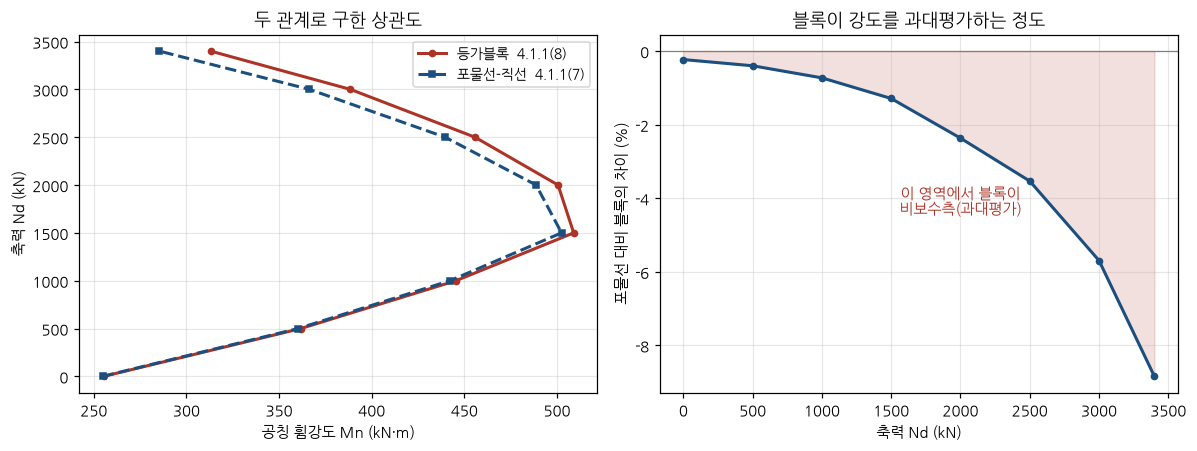

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

n_arr = np.array([r[0] for r in rows])
mb_arr = np.array([r[1] for r in rows])
mp_arr = np.array([r[2] for r in rows])

axes[0].plot(mb_arr, n_arr, "o-", color="#ad3327", lw=2, ms=4, label="등가블록  4.1.1(8)")
axes[0].plot(mp_arr, n_arr, "s--", color="#1b4f7f", lw=2, ms=4, label="포물선-직선  4.1.1(7)")
axes[0].set_xlabel("공칭 휨강도 Mn (kN·m)")
axes[0].set_ylabel("축력 Nd (kN)")
axes[0].set_title("두 관계로 구한 상관도")
axes[0].legend(fontsize=9)

diff = (mp_arr / mb_arr - 1) * 100
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].plot(n_arr, diff, "o-", color="#1b4f7f", lw=2, ms=4)
axes[1].fill_between(n_arr, diff, 0, where=diff < 0, color=C_COMP, alpha=0.15)
axes[1].set_xlabel("축력 Nd (kN)")
axes[1].set_ylabel("포물선 대비 블록의 차이 (%)")
axes[1].set_title("블록이 강도를 과대평가하는 정도")
axes[1].text(n_arr[len(n_arr) // 2], diff.min() / 2,
             "이 영역에서 블록이\n비보수측(과대평가)", ha="center",
             color=C_COMP, fontsize=10)

fig.tight_layout()
plt.show()

## 6. 이 결과를 어떻게 읽어야 하는가

축력이 커질수록 등가블록이 강도를 **과대평가**한다. 이 기둥에서는
3,000 kN 부근에서 5~6 % 다. 방향이 위험측이라는 점이 중요하다.

그렇다고 기준이 잘못된 것은 아니다. 세 가지를 함께 봐야 한다.

1. **강도감소계수가 그 영역에서 가장 낮다.** 압축지배단면은
   $\phi = 0.65$ 다. 근사 오차 6 % 는 $\phi$ 가 0.85 에서 0.65 로
   내려가며 확보한 여유 안에 들어간다. 기준은 계수를 따로따로 정한 것이
   아니라 **한 묶음으로** 정했다.
2. **최대 축강도에서 잘라 낸다.** $\alpha\phi P_o$ 상한(식 (4.1-16),
   (4.1-17)) 때문에 오차가 가장 큰 순압축 근처는 애초에 설계에 쓰이지
   않는다.
3. **정밀이 필요하면 포물선을 쓰면 된다.** 4.1.1(7)이 그래서 있다.
   기존 구조물의 잔여강도 평가처럼 여유를 정확히 알아야 하는 일에서는
   이쪽이 맞다.

## 7. 손계산 공식이 아예 없는 단면

직사각형과 T형은 손으로 풀 수 있다. 원형·중공·이형 단면은 압축부의
형상이 중립축 위치에 따라 달라져서, 폐합형 공식이 나오지 않는다.
이때는 단면을 잘라 적분하는 수밖에 없다.

**아래 코드가 하는 일** — 원형 기둥을 두 관계로 풀어 본다. 손계산으로는
어느 쪽도 구할 수 없는 값이다.

  Nd(kN)      블록 Mn      포물선 Mn        차이
------------------------------------------


       0      278.7       277.3    -0.53 %


    1000      458.1       452.7    -1.17 %


    2000      558.8       542.0    -2.99 %


    3000      486.0       457.6    -5.84 %


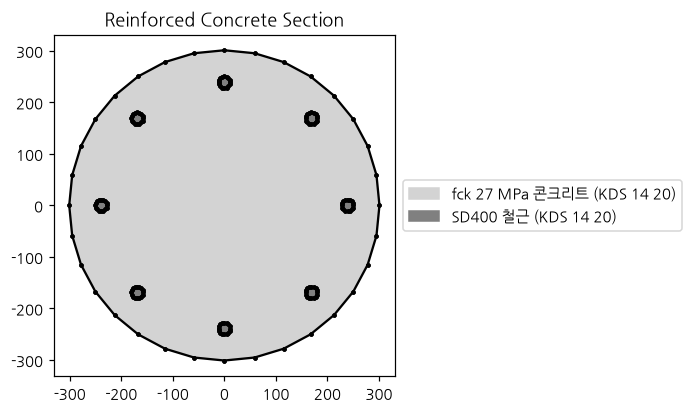

<Axes: title={'center': 'Reinforced Concrete Section'}>

In [10]:
from sectionproperties.pre.library import concrete_circular_section

def circular(fck=27, fy=400, profile="block"):
    """지름 600 mm 원형 기둥, 8-D22, 피복 50 mm."""
    kds = KDS()
    conc = kds.create_concrete_material(
        compressive_strength=fck, ultimate_profile=profile
    )
    steel = kds.create_steel_material(yield_strength=fy)
    geom = concrete_circular_section(
        d=600, area_conc=np.pi * 600 ** 2 / 4, n_conc=32,
        dia_bar=22, area_bar=387.1, n_bar=8, cover=50,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    kds.assign_concrete_section(ConcreteSection(geom))
    return kds

cb, cp = circular(profile="block"), circular(profile="parabolic")

print(f"{'Nd(kN)':>8} {'블록 Mn':>10} {'포물선 Mn':>11} {'차이':>9}")
print("-" * 42)
for n_d in [0, 1000, 2000, 3000]:
    mb = cb.ultimate_bending_capacity(n_design=n_d * 1e3)[1].m_x / 1e6
    mp = cp.ultimate_bending_capacity(n_design=n_d * 1e3)[1].m_x / 1e6
    print(f"{n_d:8.0f} {mb:10.1f} {mp:11.1f} {(mp / mb - 1) * 100:8.2f} %")

cb.concrete_section.plot_section()

## 8. 직접 바꿔 보기

**아래 코드가 하는 일** — 강도를 바꿔 가며 휨부재에서의 오차가 어떻게
변하는지 본다. 고강도일수록 포물선 곡선이 뾰족해지므로, 근사 오차가
커질 것이라 예상할 수 있다. 정말 그런지 확인한다.

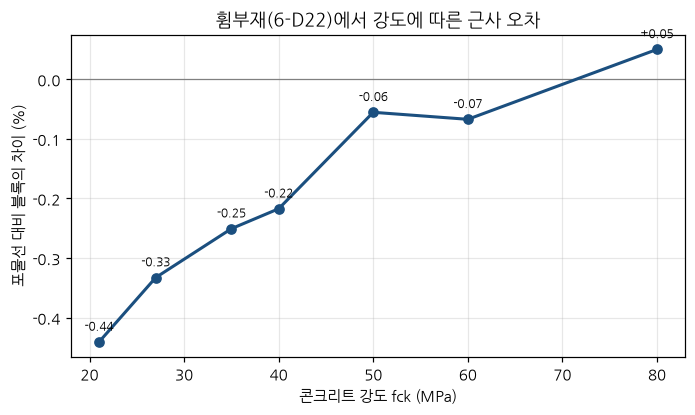

In [11]:
fck_list = [21, 27, 35, 40, 50, 60, 80]   # ← 값을 바꿔 보라
n_bar = 6                                  # ← 철근 개수도 바꿔 보라

diffs = []
for fck in fck_list:
    mb = beam(fck=fck, n_bar=n_bar, profile="block").ultimate_bending_capacity()[1].m_x
    mp = beam(fck=fck, n_bar=n_bar, profile="parabolic").ultimate_bending_capacity()[1].m_x
    diffs.append((mp / mb - 1) * 100)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.axhline(0, color="grey", lw=0.8)
ax.plot(fck_list, diffs, "o-", color="#1b4f7f", lw=2)
ax.set_xlabel("콘크리트 강도 fck (MPa)")
ax.set_ylabel("포물선 대비 블록의 차이 (%)")
ax.set_title(f"휨부재({n_bar}-D22)에서 강도에 따른 근사 오차")
for x, y in zip(fck_list, diffs):
    ax.annotate(f"{y:+.2f}", (x, y), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)
plt.show()

## 9. 생각해 볼 문제

1. **등가블록의 두 조건(면적·도심)을 맞추면 왜 단면 해석이 정확해지는가?**
   힘 평형과 모멘트 평형을 직접 써서 설명하라. 응력분포의 *모양*은 왜
   결과에 들어오지 않는가?

2. **위 5절에서 블록이 비보수측이었다.** 그런데도 기준이 블록을
   허용하는 근거를 세 가지 들었다. 그중 어느 것이 가장 결정적이라고
   보는가? 만약 $\phi$ 가 모든 단면에서 0.85 로 일정하다면 블록을
   허용해도 되겠는가?

3. **$f_{ck}$ 가 40 MPa 이하이면 $n = 2.0$, $\varepsilon_{co} = 0.002$
   로 고정이다.** 왜 40 MPa 를 경계로 삼았을까? 표 4.1-1 에서
   $\alpha$ 가 40 MPa 이후 급히 떨어지는 것과 관련지어 설명하라.

4. **기존 교량의 잔여강도를 평가하는 일을 맡았다고 하자.** 등가블록과
   포물선-직선 중 무엇을 쓰겠는가? 판단의 근거는 정확도인가, 검증
   가능성인가, 아니면 다른 것인가?

## 정리

- 등가블록은 포물선-직선 분포와 **합력의 크기와 위치를 맞춘** 근사다.
  $\eta$, $\beta_1$ 은 그 결과이지 임의의 숫자가 아니다.
- 휨부재에서는 0.3 % 이내로 맞는다. 지렛대 팔이 지배하기 때문이다.
- 축력이 커지면 오차가 커지고 **방향이 비보수측**이다. 그 영역에서
  $\phi$ 가 낮고 최대 축강도 상한이 걸리는 것과 함께 읽어야 한다.
- 원형·중공 단면에는 손계산 공식이 없다. 섬유 적분이 유일한 길이다.

조문과 구현 함수의 대응은
[설계식 목록](../user_guide/design_codes/equations.md) 에 정리되어 있다.
다음 편은 [L2 · 강도감소계수](L2_강도감소계수.ipynb) 다.